In [1]:
import pandas as pd
import numpy as np
from autogluon.tabular import TabularPredictor
import seaborn as sns
import matplotlib.pyplot as plt

np.random.seed(29)

In [2]:
odroid1 = pd.read_csv("https://raw.githubusercontent.com/brite3001/drawnapart/master/onscreen/odroid1_firefox_onscreen.csv")
odroid2 = pd.read_csv("https://raw.githubusercontent.com/brite3001/drawnapart/master/onscreen/odroid2_firefox_onscreen.csv")
odroid3 = pd.read_csv("https://raw.githubusercontent.com/brite3001/drawnapart/master/onscreen/odroid3_firefox_onscreen.csv")
odroid4 = pd.read_csv("https://raw.githubusercontent.com/brite3001/drawnapart/master/onscreen/odroid4_firefox_onscreen.csv")

In [3]:
rpi4a = pd.read_csv("https://raw.githubusercontent.com/brite3001/drawnapart/master/onscreen/rpi-4a_chrome_onscreen.csv")
rpi8a = pd.read_csv("https://raw.githubusercontent.com/brite3001/drawnapart/master/onscreen/rpi-8a_chrome_onscreen.csv")
rpi8b = pd.read_csv("https://raw.githubusercontent.com/brite3001/drawnapart/master/onscreen/rpi-8b_chrome_onscreen.csv")
rpi8c = pd.read_csv("https://raw.githubusercontent.com/brite3001/drawnapart/master/onscreen/rpi-8c_chrome_onscreen.csv")
rpi8d = pd.read_csv("https://raw.githubusercontent.com/brite3001/drawnapart/master/onscreen/rpi-8d_chrome_onscreen.csv")

In [4]:
df = pd.concat([odroid1[:2000], odroid2[:2000], odroid3[:2000], odroid4[:2000], rpi4a[:2000], rpi8a[:2000], rpi8b[:2000], rpi8c[:2000], rpi8d[:2000]])
df = df.sample(frac=1).reset_index(drop=True)

In [5]:
len(df)

18000

In [6]:
train_data = df.head(6000)
test_data = df.tail(12000)

In [8]:
train_data

,label,Feature 0,Feature 1,Feature 2,Feature 3,Feature 4,Feature 5,Feature 6
0,odroid2,186.0,10.0,150.0,350.0,167.0,167.0,166.0
1,rpi-4a,16.2,17.4,1446.0,17.8,435.5,17.1,19.3
2,odroid1,165.0,167.0,167.0,168.0,169.0,166.0,168.0
3,odroid4,169.0,175.0,176.0,174.0,174.0,173.0,173.0
4,rpi-8c,24.9,629.1,16.7,2092.1,16.1,17.3,17.6
...,...,...,...,...,...,...,...,...
5995,odroid1,166.0,170.0,167.0,169.0,166.0,168.0,168.0
5996,odroid2,180.0,172.0,156.0,172.0,170.0,12.0,166.0
5997,odroid4,170.0,175.0,175.0,173.0,174.0,175.0,173.0
5998,rpi-4a,620.7,400.1,19.8,18.2,21.0,18.9,19.9


In [9]:
test_data

,label,Feature 0,Feature 1,Feature 2,Feature 3,Feature 4,Feature 5,Feature 6
6000,odroid4,173.0,172.0,174.0,174.0,171.0,172.0,173.0
6001,odroid3,165.0,167.0,168.0,166.0,167.0,167.0,164.0
6002,odroid4,170.0,174.0,173.0,173.0,174.0,173.0,171.0
6003,rpi-8d,16.1,17.8,17.4,781.8,17.6,19.1,19.1
6004,odroid4,172.0,173.0,175.0,174.0,174.0,174.0,175.0
...,...,...,...,...,...,...,...,...
17995,rpi-8a,230.7,231.9,433.3,16.6,232.2,233.2,433.4
17996,odroid1,166.0,169.0,168.0,167.0,168.0,167.0,169.0
17997,odroid1,329.0,169.0,168.0,168.0,167.0,167.0,168.0
17998,rpi-8a,416.6,229.9,16.2,216.5,416.5,233.2,433.5


In [10]:
predictor = TabularPredictor.load("../models/classification")

# Synthetic Adversarial Example - Naive

In [11]:
naive_results = pd.DataFrame(columns=['Interval', 'accuracy', 'balanced_accuracy', 'mcc'])
for i in range(1,26):
    print(i)
    noise = np.random.uniform(-i, i, size=(len(test_data), len(test_data.columns) - 1))
    naive_adversary = test_data.iloc[:, 1:] + noise
    naive_adversary = np.round(naive_adversary, decimals=1)
    naive_adversary['label'] = test_data.iloc[:, :1]

    y_pred = predictor.predict(naive_adversary)
    y_pred_proba = predictor.predict_proba(naive_adversary)
    results = predictor.evaluate(naive_adversary)

    new_results = {'Interval':i, 'accuracy':results['accuracy'], 'balanced_accuracy':results['balanced_accuracy'], 'mcc':results['mcc']}
    naive_results.loc[len(naive_results)] = (new_results)

1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25


In [12]:
naive_results

,Interval,accuracy,balanced_accuracy,mcc
0,1,0.866917,0.867244,0.850437
1,2,0.831083,0.831375,0.810425
2,3,0.782833,0.783210,0.757531
3,4,0.746750,0.747143,0.718786
4,5,0.709917,0.710256,0.679270
5,6,0.681417,0.681746,0.648629
6,7,0.655667,0.656082,0.619240
7,8,0.636583,0.637037,0.597994
8,9,0.615167,0.615620,0.573757
9,10,0.603750,0.604216,0.561077


## Which uniform intervals are able to fool the model?

<Axes: xlabel='Interval', ylabel='value'>

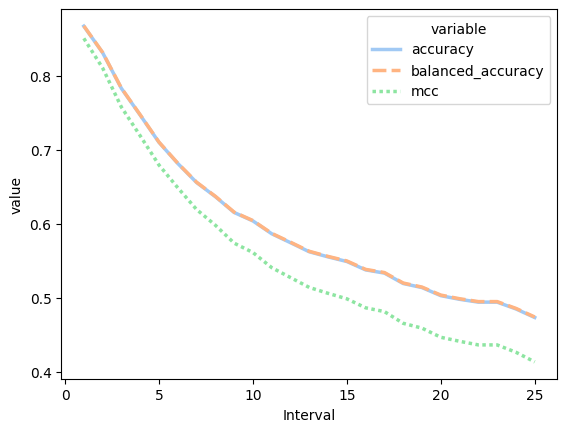

In [13]:
sns.lineplot(data=pd.melt(naive_results, ['Interval']), x='Interval', y='value', style="variable", hue='variable', palette="pastel", linewidth=2.5)

0.1 - 2.5 are able to fool the classification model with high accuracy

## Given an adversary uses an interval of 1, which IoT devices are most vulnerable to impersonation attacks?

In [14]:
naive_results = pd.DataFrame(columns=['Interval', 'accuracy', 'balanced_accuracy', 'mcc'])

noise = np.random.uniform(-1, 1, size=(len(test_data), len(test_data.columns) - 1))
naive_adversary = test_data.iloc[:, 1:] + noise
naive_adversary = np.round(naive_adversary, decimals=1)
naive_adversary['label'] = test_data.iloc[:, :1]

y_pred = predictor.predict(naive_adversary)
y_pred_proba = predictor.predict_proba(naive_adversary)
results = predictor.evaluate(naive_adversary)

new_results = {'Interval':i, 'accuracy':results['accuracy'], 'balanced_accuracy':results['balanced_accuracy'], 'mcc':results['mcc']}
naive_results.loc[len(naive_results)] = (new_results)

In [15]:
devices_fooled = pd.DataFrame(columns=['device', 'accuracy'])
for device in list(y_pred.unique()):
    devices_fooled.loc[len(devices_fooled)] = {'device': device, 'accuracy': 0.0}

for pred, label in zip(list(y_pred), list(naive_adversary['label'])):
    if pred == label:
        devices_fooled.loc[devices_fooled['device'] == pred, 'accuracy'] += 1

for device in list(y_pred.unique()):
    devices_fooled.loc[devices_fooled['device'] == device, 'accuracy'] /= list(naive_adversary['label']).count(device)

devices_fooled['accuracy'] *= 100

### All devices are vulerable to this attack

<Axes: xlabel='device', ylabel='accuracy'>

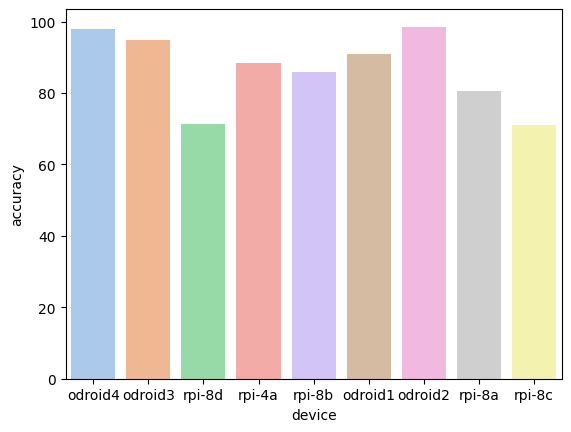

In [16]:
sns.barplot(data=devices_fooled, x='device', y='accuracy', hue='device', palette="pastel", legend=False, linewidth=2.5)

# Training anomaly detection model

Test/train data split:

We have 18k rows of IoT GPU Data
training data (5k) - genuine data
training data - held out (1k), used for testing on genuine unseen data.
testing data (12k) - impersonation data (we assume this data has been intercepted by an attacker, will be used for testing tolerance to noise on unseen data.)

Training split:
training_data.head(4500) - will be kept unmodified, genuine
training_data.head(4500) + noise - impersonation data used for training. using uniform intervals (1,25)

Test Split:
training_data.tail(1500) - genuine data that was held out from training.
testing data (1k) + noise - impersonation data used for testing. using uniform intervals (1,25)


## Training Data

### Genuine

In [7]:
genuine_training_data = train_data.head(4500).copy(deep=True)
genuine_training_data['label'] = 'genuine'

### Impersonator

In [8]:
impersonation_training_data = train_data.head(4500).drop(columns='label')

noise = np.round(np.random.uniform(low=-25, high=25, size=[4500,7]), 1)

impersonation_training_data = impersonation_training_data + noise

impersonation_training_data['label'] = 'impersonator'
impersonation_training_data

,Feature 0,Feature 1,Feature 2,Feature 3,Feature 4,Feature 5,Feature 6,label
0,177.7,5.5,163.0,336.6,178.5,188.9,180.2,impersonator
1,40.4,19.1,1448.4,-7.2,448.7,18.5,-5.4,impersonator
2,156.5,184.2,158.1,159.1,146.3,187.9,177.6,impersonator
3,164.5,155.0,189.2,173.6,157.2,166.5,161.3,impersonator
4,12.3,644.4,19.0,2079.7,-1.0,5.6,16.8,impersonator
...,...,...,...,...,...,...,...,...
4495,153.4,160.0,192.6,152.6,168.8,180.1,189.6,impersonator
4496,144.2,143.9,192.4,155.5,159.8,169.6,165.6,impersonator
4497,167.8,174.4,164.3,183.4,183.6,162.5,180.4,impersonator
4498,231.4,398.9,232.8,41.9,196.9,401.0,246.2,impersonator


<Axes: >

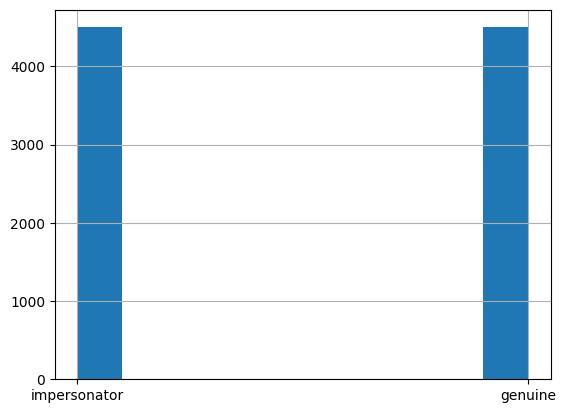

In [9]:
combined_training = pd.concat([impersonation_training_data, genuine_training_data])
combined_training = combined_training.sample(frac=1)
combined_training['label'].hist()

In [16]:
combined_training.to_csv('naive_training.csv')

## Testing Dataset

### Impersonator

In [11]:
impersonation_testing_data = test_data.drop(columns=['label'])[:1500]
noise = np.round(np.random.uniform(low=-25, high=25, size=[1500,7]), 1)

impersonation_testing_data = impersonation_testing_data + noise

impersonation_testing_data['label'] = 'impersonator'
impersonation_testing_data


,Feature 0,Feature 1,Feature 2,Feature 3,Feature 4,Feature 5,Feature 6,label
6000,190.6,174.9,167.3,151.4,147.0,170.9,154.3,impersonator
6001,158.1,182.1,159.3,172.8,174.8,151.5,153.6,impersonator
6002,185.6,183.6,169.4,163.0,182.0,196.5,168.9,impersonator
6003,6.9,-2.6,-1.5,766.0,38.2,24.1,25.5,impersonator
6004,196.9,149.3,172.1,179.4,154.1,165.5,184.2,impersonator
...,...,...,...,...,...,...,...,...
7495,-5.9,-6.7,1389.7,193.3,33.9,31.8,-1.1,impersonator
7496,2.1,5.9,1584.7,0.4,8.5,4.6,40.2,impersonator
7497,150.7,176.6,156.9,191.4,17.5,187.4,323.6,impersonator
7498,436.1,13.0,250.9,215.7,238.7,209.1,469.1,impersonator


### Genuine

In [12]:
testing_genuine = train_data.tail(1500).copy(deep=True)
testing_genuine['label'] = 'genuine'


<Axes: >

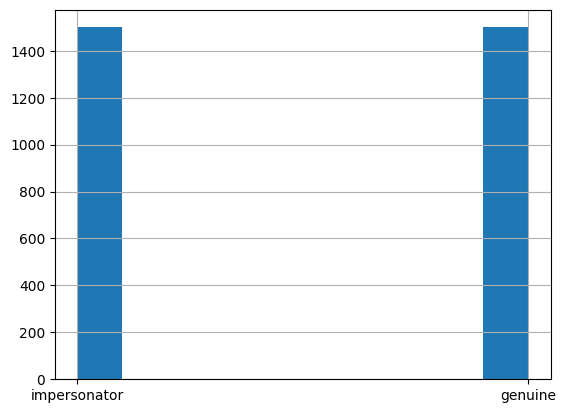

In [13]:
combined_testing = pd.concat([impersonation_testing_data, testing_genuine])
combined_testing['label'].hist()

In [15]:
combined_testing.to_csv('naive_testing.csv')

In [25]:
results_df = pd.DataFrame(columns=['data_amount', 'accuracy', 'balanced_accuracy', 'mcc'])

for training_data_size in range(1000, 10000, 1000):
    print(training_data_size)

    impersonation_detector = TabularPredictor(label='label').fit(combined_training[:training_data_size], num_gpus=1, presets='medium_quality', fit_weighted_ensemble=False)
    
    y_pred = impersonation_detector.predict(combined_testing)
    y_pred_proba = impersonation_detector.predict_proba(combined_testing)
    results = impersonation_detector.evaluate(combined_testing)

    new_results = {'data_amount':training_data_size, 'accuracy':results['accuracy'], 'balanced_accuracy':results['balanced_accuracy'], 'mcc':results['mcc']}
    results_df.loc[len(results_df)] = (new_results)

No path specified. Models will be saved in: "AutogluonModels\ag-20250330_233200"
Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.2
Python Version:     3.11.11
Operating System:   Windows
Platform Machine:   AMD64
Platform Version:   10.0.26100
CPU Count:          32
Memory Avail:       54.99 GB / 63.72 GB (86.3%)
Disk Space Avail:   958.74 GB / 1906.98 GB (50.3%)
Presets specified: ['medium_quality']
Beginning AutoGluon training ...
AutoGluon will save models to "c:\Users\zac\Documents\github\IoT-GPU-ID\Experiment 2 - Spoofing Attack Detection\AutogluonModels\ag-20250330_233200"
Train Data Rows:    1000
Train Data Columns: 7
Label Column:       label
AutoGluon infers your prediction problem is: 'binary' (because only two unique label-values observed).
	2 unique label values:  ['genuine', 'impersonator']
	If 'binary' is not the correct problem_type, please manually specify the problem_type parameter during Predictor init (You may

1000


	0.925	 = Validation score   (accuracy)
	1.33s	 = Training   runtime
	0.01s	 = Validation runtime
Fitting model: LightGBM ...
	Training LightGBM with GPU, note that this may negatively impact model quality compared to CPU training.
	0.95	 = Validation score   (accuracy)
	1.64s	 = Training   runtime
	0.01s	 = Validation runtime
Fitting model: RandomForestGini ...
	0.945	 = Validation score   (accuracy)
	0.34s	 = Training   runtime
	0.03s	 = Validation runtime
Fitting model: RandomForestEntr ...
	0.945	 = Validation score   (accuracy)
	0.32s	 = Training   runtime
	0.03s	 = Validation runtime
Fitting model: CatBoost ...
		Import catboost failed. Numpy version may be outdated, Please ensure numpy version >=1.17.0. If it is not, please try 'pip uninstall numpy -y; pip install numpy>=1.17.0' Detailed info: numpy.dtype size changed, may indicate binary incompatibility. Expected 96 from C header, got 88 from PyObject
Fitting model: ExtraTreesGini ...
	0.9	 = Validation score   (accuracy)
	0.32

2000
[1000]	valid_set's binary_error: 0.0425


	0.96	 = Validation score   (accuracy)
	3.6s	 = Training   runtime
	0.01s	 = Validation runtime
Fitting model: LightGBM ...
	Training LightGBM with GPU, note that this may negatively impact model quality compared to CPU training.
	0.965	 = Validation score   (accuracy)
	2.5s	 = Training   runtime
	0.01s	 = Validation runtime
Fitting model: RandomForestGini ...
	0.9575	 = Validation score   (accuracy)
	0.34s	 = Training   runtime
	0.03s	 = Validation runtime
Fitting model: RandomForestEntr ...
	0.9575	 = Validation score   (accuracy)
	0.3s	 = Training   runtime
	0.03s	 = Validation runtime
Fitting model: CatBoost ...
		Import catboost failed. Numpy version may be outdated, Please ensure numpy version >=1.17.0. If it is not, please try 'pip uninstall numpy -y; pip install numpy>=1.17.0' Detailed info: numpy.dtype size changed, may indicate binary incompatibility. Expected 96 from C header, got 88 from PyObject
Fitting model: ExtraTreesGini ...
	0.9125	 = Validation score   (accuracy)
	0.

...

	0.9557	 = Validation score   (accuracy)
	3.66s	 = Training   runtime
	0.01s	 = Validation runtime
Fitting model: LightGBM ...
	Training LightGBM with GPU, note that this may negatively impact model quality compared to CPU training.
	0.9671	 = Validation score   (accuracy)
	2.39s	 = Training   runtime
	0.01s	 = Validation runtime
Fitting model: RandomForestGini ...
	0.9686	 = Validation score   (accuracy)
	0.47s	 = Training   runtime
	0.04s	 = Validation runtime
Fitting model: RandomForestEntr ...
	0.9686	 = Validation score   (accuracy)
	0.46s	 = Training   runtime
	0.04s	 = Validation runtime
Fitting model: CatBoost ...
		Import catboost failed. Numpy version may be outdated, Please ensure numpy version >=1.17.0. If it is not, please try 'pip uninstall numpy -y; pip install numpy>=1.17.0' Detailed info: numpy.dtype size changed, may indicate binary incompatibility. Expected 96 from C header, got 88 from PyObject
Fitting model: ExtraTreesGini ...
	0.9457	 = Validation score   (accurac

8000


	0.9487	 = Validation score   (accuracy)
	4.47s	 = Training   runtime
	0.02s	 = Validation runtime
Fitting model: LightGBM ...
	Training LightGBM with GPU, note that this may negatively impact model quality compared to CPU training.
	0.97	 = Validation score   (accuracy)
	2.96s	 = Training   runtime
	0.01s	 = Validation runtime
Fitting model: RandomForestGini ...
	0.96	 = Validation score   (accuracy)
	0.48s	 = Training   runtime
	0.05s	 = Validation runtime
Fitting model: RandomForestEntr ...
	0.9575	 = Validation score   (accuracy)
	0.47s	 = Training   runtime
	0.05s	 = Validation runtime
Fitting model: CatBoost ...
		Import catboost failed. Numpy version may be outdated, Please ensure numpy version >=1.17.0. If it is not, please try 'pip uninstall numpy -y; pip install numpy>=1.17.0' Detailed info: numpy.dtype size changed, may indicate binary incompatibility. Expected 96 from C header, got 88 from PyObject
Fitting model: ExtraTreesGini ...
	0.9413	 = Validation score   (accuracy)
	

9000


	0.9567	 = Validation score   (accuracy)
	3.7s	 = Training   runtime
	0.0s	 = Validation runtime
Fitting model: LightGBM ...
	Training LightGBM with GPU, note that this may negatively impact model quality compared to CPU training.
	0.9722	 = Validation score   (accuracy)
	3.0s	 = Training   runtime
	0.02s	 = Validation runtime
Fitting model: RandomForestGini ...
	0.9656	 = Validation score   (accuracy)
	0.48s	 = Training   runtime
	0.04s	 = Validation runtime
Fitting model: RandomForestEntr ...
	0.9656	 = Validation score   (accuracy)
	0.49s	 = Training   runtime
	0.04s	 = Validation runtime
Fitting model: CatBoost ...
		Import catboost failed. Numpy version may be outdated, Please ensure numpy version >=1.17.0. If it is not, please try 'pip uninstall numpy -y; pip install numpy>=1.17.0' Detailed info: numpy.dtype size changed, may indicate binary incompatibility. Expected 96 from C header, got 88 from PyObject
Fitting model: ExtraTreesGini ...
	0.9411	 = Validation score   (accuracy)


In [30]:
impersonation_detector.feature_importance(combined_testing, subsample_size=5000, num_shuffle_sets=10)

Computing feature importance via permutation shuffling for 7 features using 3000 rows with 10 shuffle sets...
	1.48s	= Expected runtime (0.15s per shuffle set)
	0.33s	= Actual runtime (Completed 10 of 10 shuffle sets)


,importance,stddev,p_value,n,p99_high,p99_low
Feature 5,0.037800,0.003739,7.041317e-11,10,0.041643,0.033957
Feature 6,0.030700,0.003599,3.198009e-10,10,0.034398,0.027002
Feature 0,0.022600,0.002571,2.454043e-10,10,0.025243,0.019957
Feature 4,0.021667,0.001707,9.198913e-12,10,0.023421,0.019912
Feature 3,0.020100,0.001248,1.086327e-12,10,0.021382,0.018818
Feature 1,0.015867,0.002928,1.765577e-08,10,0.018876,0.012858
Feature 2,0.008567,0.001714,3.587845e-08,10,0.010329,0.006805


In [26]:
impersonation_detector.leaderboard()

,model,score_val,eval_metric,pred_time_val,fit_time,pred_time_val_marginal,fit_time_marginal,stack_level,can_infer,fit_order
0,XGBoost,0.972222,accuracy,0.008339,1.450261,0.008339,1.450261,1,True,10
1,LightGBMLarge,0.972222,accuracy,0.014154,6.044458,0.014154,6.044458,1,True,12
2,LightGBM,0.972222,accuracy,0.016329,3.003304,0.016329,3.003304,1,True,4
3,RandomForestEntr,0.965556,accuracy,0.044641,0.486140,0.044641,0.486140,1,True,6
4,RandomForestGini,0.965556,accuracy,0.044682,0.481491,0.044682,0.481491,1,True,5
5,LightGBMXT,0.956667,accuracy,0.001188,3.699698,0.001188,3.699698,1,True,3
6,ExtraTreesEntr,0.948889,accuracy,0.045624,0.413245,0.045624,0.413245,1,True,8
7,ExtraTreesGini,0.941111,accuracy,0.044801,0.412055,0.044801,0.412055,1,True,7
8,NeuralNetTorch,0.927778,accuracy,0.000000,67.718050,0.000000,67.718050,1,True,11
9,KNeighborsUnif,0.675556,accuracy,0.023880,0.010013,0.023880,0.010013,1,True,1


## How much data is needed for decent model accuracy?

1500 noisy impersonator / 1500 genuine rows enough to train accurate model

<Axes: xlabel='data_amount', ylabel='value'>

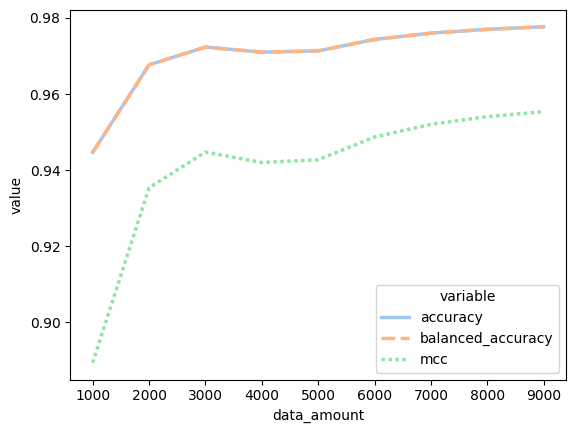

In [27]:
sns.lineplot(data=pd.melt(results_df, ['data_amount']), x='data_amount', y='value', style="variable", hue='variable', palette="pastel", linewidth=2.5)